In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import orbit_count
from scipy.stats import sem, loguniform, beta, uniform
from random import choice

# Utils
from datetime import datetime
from collections import Counter
import itertools
from io import BytesIO
import random


# Data preprocessing and trasformation (ETL)
from sklearn.preprocessing import StandardScaler, MinMaxScaler,OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Unsupervised
from sklearn.manifold import TSNE

# Supervised Learning
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, KFold, StratifiedKFold, RepeatedKFold, learning_curve, validation_curve, RandomizedSearchCV, cross_validate
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve, roc_curve, accuracy_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# NLP
from gensim.models.word2vec import Word2Vec

# Visualization
import matplotlib.pyplot as plt
import matplotlib as mpl
from mycolorpy import colorlist as mcp

# Warning suppression
import warnings
warnings.filterwarnings('ignore')

## A step back: Word2Vec

![](slides/graph_ml_40.png)
![](slides/graph_ml_42.png)
**Word2Vec** is a group of models that are used to produce word embeddings—vector representations of words. These embeddings capture semantic relationships between words, meaning that words with similar meanings are mapped to vectors that are close to each other in the vector space. This property allows Word2Vec to translate words into vectors such that semantically similar words have close vectors.

To generate these embeddings, the model is **trained on a large corpus of text data**. Through this training, Word2Vec learns **word associations from the context** in which words appear. Once trained, the model can predict a word given its context or predict the context given a word.

There are two main architectures for training Word2Vec models:

### The Continuous Bag-of-Words (CBOW) Model

The **CBOW model** is trained to **predict a target word based on its surrounding context** words. These context words are the words that come before and after the target word within a specified **window size** or **context**. In the CBOW model, the **order of the context words** does **not matter** because their embeddings are summed (or averaged) to predict the target word. This approach assumes that the context words collectively contribute to the meaning of the target word.

**Example:**

Consider the sentence:

> "The quick brown fox jumps over the lazy dog."

If we set the context window size to 2, and our target word is "fox," the context words would be ["quick", "brown", "jumps", "over"]. The CBOW model uses these context words to predict the target word "fox."

### The Continuous Skip-Gram Model

The **skip-gram model** operates in the opposite way. Here, the model is trained to **predict the surrounding context words given a single target word**. Essentially, for each word in the corpus, the model tries to predict the words that are likely to appear near it within a certain window size. This approach focuses on learning high-quality word embeddings even for rare words by leveraging the contexts in which they appear.

**Example:**

Using the same sentence and context window size as before, if our target word is "fox," the model attempts to predict the context words ["quick", "brown", "jumps", "over"] based solely on "fox."

**Increasing the range** of context words (i.e., increasing the window size) generally leads to **better embeddings** because the model captures a broader context. However, this also increases the training time and computational complexity, as the number of word pairs the model needs to consider grows.

![](slides/graph_ml_43.png)
![](slides/graph_ml_44.png)
![](slides/graph_ml_45.png)

We focus on the skip-gram model because it's the one used by **DeepWalk**, a framework for learning latent representations of vertices in a graph. DeepWalk **treats random walks on a graph similarly to sentences in a text corpus**. It uses the skip-gram model to learn embeddings for nodes (vertices) in the graph based on these random walks.

### Skip-Grams in DeepWalk

In the context of DeepWalk, the "sentences" are sequences of nodes generated by random walks on the graph. The skip-grams of a sentence are a series of pairs of nodes:

```
(target_node, context_node)
```

For each node in the random walk (the `target_node`), the `context_nodes` are the nodes around it within a certain number of steps, defined by the `CONTEXT_SIZE` parameter.

**Example:**

Consider a random walk through a graph:

> A → B → C → D → E

With a `CONTEXT_SIZE` of 2, the skip-gram pairs generated would be:

- For target node "C," the context nodes are ["A", "B", "D", "E"].
- The skip-gram pairs are:
  - ("C", "A")
  - ("C", "B")
  - ("C", "D")
  - ("C", "E")

By feeding these skip-gram pairs into the model, DeepWalk learns embeddings for each node that capture the structural relationships and community structures within the graph.

### Why Skip-Gram for DeepWalk?

The skip-gram model is particularly well-suited for DeepWalk because:

- **Flexibility with Rare Nodes:** Skip-gram tends to perform better with infrequent nodes in the graph, similar to how it handles rare words in text corpora.
- **Capturing Structural Similarities:** It effectively captures the similarity between nodes based on their neighborhoods, which is essential for tasks like node classification or link prediction.
- **Efficiency:** Despite considering a wide context, the skip-gram model remains computationally efficient, making it practical for large graphs.

---

By utilizing the skip-gram model within DeepWalk, we can learn meaningful and efficient node embeddings that reflect the graph's topology and the relationships between nodes. This approach enables various downstream tasks, such as clustering, visualization, and prediction, by leveraging the learned embeddings.

In practice, here we show how Word2Vec works for a small corpus of text. The embeddding is learn by the skip-gram approach.

In [2]:
np.random.seed(0)  # Ensure reproducibility

CONTEXT_SIZE = 2  # Number of context words to consider on each side

# Multiline string containing the text corpus
text = """Occupied in observing Mr. Bingley's attentions to her sister, 
Elizabeth was far from suspecting that she was herself becoming an object of some interest in the eyes of his friend. 
Mr. Darcy had at first scarcely allowed her to be pretty; he had looked at her without admiration at the ball; 
and when they next met, he looked at her only to criticize. But no sooner had he made it clear to himself 
and his friends that she had hardly a good feature in her face, than he began to find it was rendered uncommonly 
intelligent by the beautiful expression of her dark eyes. To this discovery succeeded some others equally mortifying. 
Though he had detected with a critical eye more than one failure of perfect symmetry in her form, 
he was forced to acknowledge her figure to be light and pleasing; and in spite of his asserting that her manners 
were not those of the fashionable world, he was caught by their easy playfulness. 
Of this she was perfectly unaware;to her he was only the man who made himself agreeable nowhere, 
and who had not thought her handsome enough to dance with. He began to wish to know more of her, and as a 
step towards conversing with her himself, attended to her conversation with others""".split()

# Initialize an empty list to store the skip-gram pairs
skipgrams = []

# Loop over the text to generate skip-gram pairs
for i in range(CONTEXT_SIZE, len(text) - CONTEXT_SIZE):
    # Collect context words within the context window, excluding the target word
    array = [
        text[j]  # Context word
        for j in np.arange(i - CONTEXT_SIZE, i + CONTEXT_SIZE + 1)  # Indices in the context window
        if j != i  # Exclude the target word itself
    ]
    # Add the target word and its context words as a tuple to the list
    skipgrams.append((text[i], array))

# Display the first two skip-gram pairs
print(skipgrams[:2])


[('observing', ['Occupied', 'in', 'Mr.', "Bingley's"]), ('Mr.', ['in', 'observing', "Bingley's", 'attentions'])]


#### Code Explanation

Let's break down the provided Python code step by step to understand how it generates skip-gram pairs from a text corpus. The skip-gram model is used in natural language processing to predict context words given a target word within a certain window size.


```python
# Create skipgrams
skipgrams = []
for i in range(CONTEXT_SIZE, len(text) - CONTEXT_SIZE):
    array = [text[j] for j in np.arange(i - CONTEXT_SIZE, i + CONTEXT_SIZE + 1) if j != i]
    skipgrams.append((text[i], array))
```

- **Initializing the Skip-Grams List**: An empty list `skipgrams` is created to store the (target word, context words) pairs.
- **Iterating Over the Words**:
  - The `for` loop iterates over each word in the text, starting from index `CONTEXT_SIZE` and ending at `len(text) - CONTEXT_SIZE`. This ensures that there are enough context words on both sides of the target word.
- **Generating Context Words**:
  - For each target word `text[i]`, we collect context words.
  - `np.arange(i - CONTEXT_SIZE, i + CONTEXT_SIZE + 1)` generates a range of indices covering the context window around the target word.
  - The condition `if j != i` excludes the target word itself from the context words.
- **Appending to the Skip-Grams List**:
  - Each tuple `(text[i], array)` contains the target word and its corresponding context words.
  - This tuple is appended to the `skipgrams` list.


**Sample Output and Interpretation**

Suppose the first few words of the `text` list are:

```
Index: 0         1        2           3          4           5
Words: 'Occupied', 'in', 'observing', 'Mr.', "Bingley's", 'attentions', ...
```

**First Iteration (`i = 2`)**

- **Target Word**: `'observing'`
- **Context Indices**: `0, 1, 3, 4` (excluding `i = 2`)
- **Context Words**: `['Occupied', 'in', 'Mr.', "Bingley's"]`
- **Skip-Gram Pair**: `('observing', ['Occupied', 'in', 'Mr.', "Bingley's"])`

**Second Iteration (`i = 3`)**

- **Target Word**: `'Mr.'`
- **Context Indices**: `1, 2, 4, 5` (excluding `i = 3`)
- **Context Words**: `['in', 'observing', "Bingley's", 'attentions']`
- **Skip-Gram Pair**: `('Mr.', ['in', 'observing', "Bingley's", 'attentions'])`

**Printed Output**:

```python
[
 ('observing', ['Occupied', 'in', 'Mr.', "Bingley's"]),
 ('Mr.', ['in', 'observing', "Bingley's", 'attentions'])
]
```


In [3]:
vocab = set(text) # how many unique words we have
VOCAB_SIZE = len(vocab)
print(f"Length of vocabulary = {VOCAB_SIZE}")

Length of vocabulary = 129


Here we demonstrate how to create and train a `Word2Vec` model using the `gensim` library. The model uses the skip-gram architecture to learn word embeddings from a given text corpus.

In [4]:
# Create Word2Vec model
model = Word2Vec(
    [text],        # Training data (list of sentences)
    sg=1,          # Use skip-gram architecture
    vector_size=10,# Embedding dimension
    min_count=0,   # Include all words
    window=2,      # Context window size
    workers=1,     # Number of worker threads
    seed=0         # Random seed for reproducibility
)

# Print the shape of the embedding matrix
print(f'Shape of W_embed: {model.wv.vectors.shape}')  # Should be (vocab_size, vector_size)

# Train the model
_ = model.train(
    [text],                         # Training data
    total_examples=model.corpus_count,  # Number of sentences
    epochs=10                       # Number of iterations over the corpus
)


Shape of W_embed: (129, 10)


```python
# Create Word2Vec
model = Word2Vec([text],
                 sg=1,   # Skip-gram
                 vector_size=10,
                 min_count=0,
                 window=2,
                 workers=1,
                 seed=0)
```

- **Word2Vec Model Initialization**:
  - The `Word2Vec` class from the `gensim` library is used to create the model.
  - **Parameters**:
    - **`[text]`**: The input corpus, which is a list of sentences. Each sentence is a list of words. Here, `text` is a list of words, so we wrap it in another list to make it a list of sentences.
    - **`sg=1`**: Specifies the training algorithm. `1` means skip-gram model, while `0` would mean CBOW (Continuous Bag-of-Words) model.
    - **`vector_size=10`**: Sets the dimensionality of the word vectors (**embedding size**). Each word will be represented by a 10-dimensional vector.
    - **`min_count=0`**: Ignores all words with total frequency lower than this. Setting it to `0` ensures that all words in the corpus are considered, even those that appear only once.
    - **`window=2`**: The maximum distance between the current and predicted word within a sentence. It defines the **context window size** to be 2 words on each side of the target word.
    - **`workers=1`**: The number of worker threads used for training. Using `1` means the training will be done on a single thread.
    - **`seed=0`**: Sets the random number generator's seed to ensure reproducibility of results.

```python
# Train model
model.train([text], total_examples=model.corpus_count, epochs=10)
```

- **Training the Word2Vec Model**:
  - **`model.train()`**: Trains the Word2Vec model on the provided corpus.
  - **Parameters**:
    - **`[text]`**: The training corpus, provided as a list of sentences (each sentence is a list of words).
    - **`total_examples=model.corpus_count`**: The total number of sentences in the corpus. `model.corpus_count` automatically calculates this based on the input corpus during initialization.
    - **`epochs=10`**: The number of iterations (epochs) over the corpus for training.

### 6. Sample Output

Assuming the first word in `text` is `'Occupied'`, the output might look like:

```
Shape of W_embed: (154, 10)

Word embedding =
[-0.00130619  0.00798778 -0.00837129  0.00383087 -0.00560888  0.00725954
 -0.00360387 -0.00925593  0.00383689 -0.00887561]
```

- **Interpretation**:
  - The embedding is a 10-dimensional vector representing the word `'Occupied'`.
  - These values are learned during training and capture the semantic relationships based on the skip-gram model.

In [5]:
model.wv.most_similar(positive=['eyes'])[:5]

[('Mr.', 0.6868850588798523),
 ('made', 0.6483732461929321),
 ('when', 0.5913781523704529),
 ('of', 0.5659167170524597),
 ('handsome', 0.5486819744110107)]

## Sentences in graphs: random walks

In the realm of network analysis and graph theory, one innovative approach to understanding and representing complex graphs is by treating **sequences of nodes as sentences and individual nodes as words**. This analogy stems from the method of performing **random walks** on graphs to generate sequences of nodes, which can then be analyzed using natural language processing techniques.

**Random walks** are stochastic processes that move from one node to another in a graph, choosing the next node randomly from the neighbors of the current node. By performing multiple random walks, we generate numerous sequences of nodes that capture the local and global structures of the graph.

These node sequences, akin to sentences composed of words, allow us to apply algorithms like **Word2Vec** to learn vector representations (embeddings) of nodes. Just as Word2Vec captures semantic relationships between words based on their context in sentences, it can **capture the structural and relational properties of nodes in a graph based on their co-occurrence patterns in the random walks**.

This approach enables us to transform the graph into a high-dimensional vector space where nodes with similar roles or positions in the graph have embeddings that are close to each other. These embeddings can then be used for various downstream tasks such as node classification, clustering, link prediction, and visualization.

Methods like **DeepWalk** leverage this concept by combining random walks with skip-gram models to learn latent representations of nodes. By bridging the gap between graph theory and natural language processing, we gain powerful tools to analyze and interpret complex networks in a more intuitive and computationally efficient manner.

In [6]:
random.seed(0)

We deomostrate how we can generate sentences from random walks on a network using a simple toy graph.

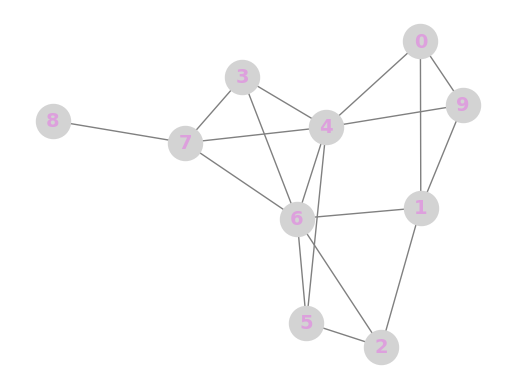

In [23]:
# Create a graph
G = nx.erdos_renyi_graph(10, 0.3, seed=1, directed=False)
pos = nx.spring_layout(G, seed = 0)

# Plot graph
plt.figure()
plt.axis('off')
nx.draw_networkx(G,
                 pos=pos,
                 node_size=600,
                 cmap='coolwarm',
                 font_size=14,
                 font_color='plum',
                 font_weight = 'bold',
                 node_color = 'lightgrey',
                 edge_color = 'grey',
                 )

In [25]:
def random_walk(G,start, length):
    walk = [str(start)]  # starting node    
    for i in range(length):
        neighbors = [node for node in G.neighbors(start)]
        next_node = np.random.choice(neighbors, 1)[0]
        walk.append(str(next_node))
        start = next_node
    return walk

We defined function `random_walk` that performs a random walk on a graph, generating a sequence of nodes. 

The function `random_walk` takes three arguments:
    - **`G`**: The graph on which the random walk is performed. Typically, this would be a graph object from a library like `networkx`.
    - **`start`**: The starting node for the random walk. This should be a node in `G`.
    - **`length`**: The number of steps (length of the walk) to perform.
  - **Output**: The function returns a list representing the sequence of nodes visited during the random walk.

A list `walk` is created to store the sequence of nodes visited during the walk and the starting node (`start`) is converted to a string and added as the first element of the walk.

Then, a loop runs for the specified number of steps (`length`), simulating the random walk. We etrieve all neighboring nodes (directly connected nodes) of the current node `start` in the graph `G` and randomly we select one node from the list of neighbors. Then we move the walker to the `next_node` and repeats the process.

### Example Execution

#### Input:
- A graph `G` with nodes and edges, such as:
  ```python
  G = nx.Graph()
  G.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 1)])
  ```
- Starting node: `1`
- Length of the walk: `3`

#### Process:
1. Initialize the walk: `walk = ['1']`.
2. Iteration 1:
   - Current node: `1`.
   - Neighbors: `[2, 4]`.
   - Randomly select: `2`.
   - Update walk: `walk = ['1', '2']`.
   - Update current node: `start = 2`.
3. Iteration 2:
   - Current node: `2`.
   - Neighbors: `[1, 3]`.
   - Randomly select: `3`.
   - Update walk: `walk = ['1', '2', '3']`.
   - Update current node: `start = 3`.
4. Iteration 3:
   - Current node: `3`.
   - Neighbors: `[2, 4]`.
   - Randomly select: `4`.
   - Update walk: `walk = ['1', '2', '3', '4']`.

#### Output:
```python
['1', '2', '3', '4']
```


We can visualize the resulting random walk through the following function `draw_walk`

In [26]:
def draw_walk(G, walk, pos, cmap_edges = 'Blues'):
    edges = []
    for i in range(1,len(walk)):
        edges.append((int(walk[i-1]),int(walk[i])))
    Gwalk = nx.MultiDiGraph(edges)
    plt.figure(figsize = (10,10))
    listnodes = [int(n) for n in walk]
    unique_nodes = []
    for n in listnodes:
        if n not in unique_nodes: unique_nodes.append(n)
   
    #posx=range(len(unique_nodes))
    #posy=len(unique_nodes)*[0]
    #pos={n:[posx[i],posy[i]] for i,n in enumerate(unique_nodes)} 

    names = {name: name for name in Gwalk.nodes}
    nx.draw_networkx_nodes(G, pos, node_color = 'lightgrey', node_size = 600, alpha = 1)
    nx.draw_networkx_edges(G, pos)
    nx.draw_networkx_labels(G,pos,names,font_size=12,font_color='w')
    ax = plt.gca()
    colors =mcp.gen_color(cmap=cmap_edges,n=G.size())
    for i,e in enumerate(Gwalk.edges):
        ax.annotate("",
                    xy=pos[e[1]], xycoords='data',
                    xytext=pos[e[0]], textcoords='data',
                    arrowprops=dict(arrowstyle="->", color=colors[i],
                                    shrinkA=10, shrinkB=10,
                                    patchA=None, patchB=None,
                                    connectionstyle="arc3,rad=0.5".replace('rrr',str(0.3*e[2])),
                                    ),
                    )
        
    plt.axis('off')
    plt.show() 
    return Gwalk

['0', '9', '4', '9', '4', '7', '4', '9', '4', '5', '2']


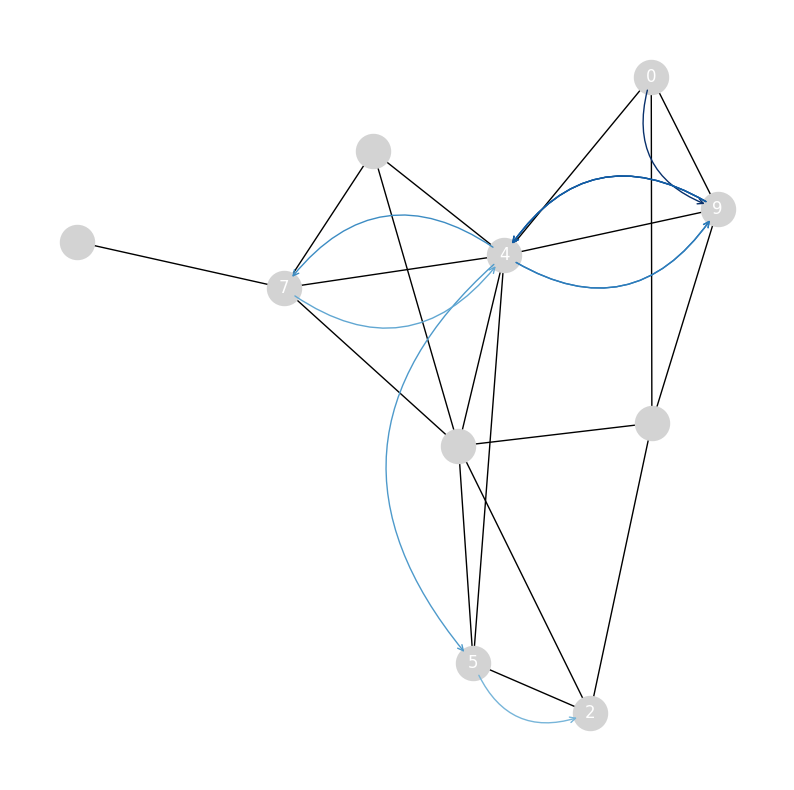

In [27]:
# Create a list of random walks
rw = random_walk(G, 0, 10)
print(rw)
Gwalk = draw_walk(G,rw, pos, 'Blues_r')

### Example on Zachary's Karate club

We apply the same process on a real toy graph, the famous Zachary's Karate Club

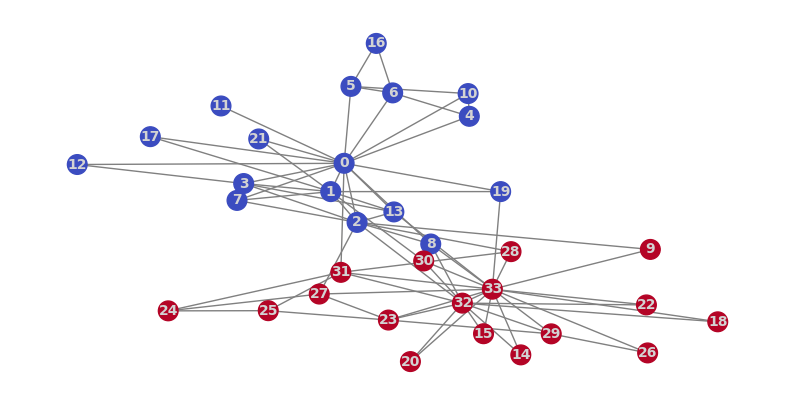

In [28]:
# Load dataset
G_karate = nx.karate_club_graph()

# Process labels (Mr. Hi = 0, Officer = 1)
labels = []
for node in G_karate.nodes:
    label = G_karate.nodes[node]['club']
    labels.append(1 if label == 'Officer' else 0)

# Plot graph
plt.figure(figsize=(10,5))
plt.axis('off')
nx.draw_networkx(G_karate,
                 pos=nx.spring_layout(G_karate, seed=0),
                 node_color=labels,
                 node_size=200,
                 cmap='coolwarm',
                font_size=10,
                 font_color='lightgrey',
                 font_weight = 'bold',
                 edge_color = 'grey',
                 )

For each node, we generate 80 different random walks, i.e. different sentences where the words are the nodes' ID.

In [29]:
# Create a list of random walks
walks = []
for node in G_karate.nodes:
    for _ in range(80):
        walks.append(random_walk(G_karate,node, 10))

# Print the first random walk for the first selected node
print(walks[0])

['0', '2', '28', '2', '28', '31', '32', '14', '33', '32', '2']


## DeepWalk: Word2Vec applied to random walks 

We train a Word2Vec model on a list of random walks (walks) generated from a graph. Each random walk is treated as a "sentence," and nodes in the walk are treated as "words." The resulting embeddings represent the nodes in a continuous vector space, capturing structural relationships in the graph.

In [30]:
# Create Word2Vec
model = Word2Vec(walks,
                 hs=1,   # Hierarchical softmax
                 sg=1,   # Skip-gram
                 vector_size=100,
                 window=5,
                 workers=1,
                 seed=1)

print(f'Shape of embedding matrix: {model.wv.vectors.shape}')

# Build vocabulary
model.build_vocab(walks)

# Train model
_ = model.train(walks, total_examples=model.corpus_count, epochs=30, report_delay=1)

Shape of embedding matrix: (34, 100)


- Word2Vec Initialization:
    - `walks`: A list of lists where each inner list is a random walk (sequence of nodes). This is the training data for the model.
    -`hs=1`: Enables hierarchical softmax for training. This is an alternative to negative sampling (default if hs=0).
    - `sg=1`: Specifies the skip-gram model. Skip-gram predicts context words given a target word, making it suitable for learning embeddings from random walks.
    -`vector_size=100`: The dimensionality of the node embeddings (number of features for each vector).
    -`window=10`: The context window size. Words (nodes) within 10 steps of the target word in a walk are considered context.
    -`workers=1`: Specifies single-threaded training. Increasing this can improve training speed on multi-core machines.
    -`seed=1`: Sets the random seed for reproducibility, ensuring consistent results across runs.

Hierarchical softmax is a technique used to efficiently compute the probabilities of a large output space, such as words in a vocabulary or nodes in a graph. It is particularly useful in models like Word2Vec where the vocabulary size can be very large, making a standard softmax computation computationally expensive.

Instead of calculating probabilities for all possible output words, hierarchical softmax organizes the vocabulary into a binary tree structure, significantly reducing the computational cost of predicting the output.

## Applications of DeepWalk model

### Find similar nodes

In graph-based machine learning, identifying nodes with similar roles or attributes is a fundamental task, crucial for applications like recommendation systems, community detection, and anomaly detection. 

To find similar nodes:
1. **Generate Embeddings**: Apply DeepWalk to obtain low-dimensional vector representations for each node in the graph.
2. **Measure Similarity**: Use metrics like cosine similarity or Euclidean distance to compare node embeddings.
3. **Interpret Results**: Nodes with high similarity scores are structurally or functionally related, depending on the context of the graph.

In [31]:
# Most similar nodes
print('Nodes that are the most similar to node 0:')
for similarity in model.wv.most_similar(positive=['0'], topn = 5):
    print(f'   {similarity}')

# Similarity between two nodes
print(f"\nSimilarity between node 0 and 4: {model.wv.similarity('0', '4')}")

Nodes that are the most similar to node 0:
   ('10', 0.6531566381454468)
   ('4', 0.635170042514801)
   ('12', 0.6285048723220825)
   ('6', 0.6046853065490723)
   ('17', 0.5988596081733704)

Similarity between node 0 and 4: 0.635170042514801


In [32]:
print(f"\nSimilarity between node 0 and 19: {model.wv.similarity('0', '19')}")
print(f"\nSimilarity between node 0 and 18: {model.wv.similarity('0', '18')}")


Similarity between node 0 and 19: 0.3496536612510681

Similarity between node 0 and 18: 0.016714826226234436


### Visualize embeddings in 2D space

Graph embeddings learned through **DeepWalk** capture the complex relationships and structural properties of nodes in a graph, mapping them to a high-dimensional vector space. While these embeddings are powerful for tasks like clustering, classification, and link prediction, their high dimensionality can make interpretation challenging.

To facilitate understanding and interpretation, embeddings can be projected into a **2D space** for visualization. This enables:
1. **Pattern Recognition**: Observing clusters of nodes that share similar roles or properties in the graph.
2. **Community Insights**: Identifying groups of densely connected nodes or communities.
3. **Anomaly Detection**: Spotting outliers or unusual nodes in the graph structure.

Common techniques for dimensionality reduction, such as **t-SNE** or **PCA**, are applied to compress the high-dimensional embeddings into two dimensions while preserving meaningful relationships. The resulting 2D visualization provides an intuitive and interpretable representation of the graph structure.

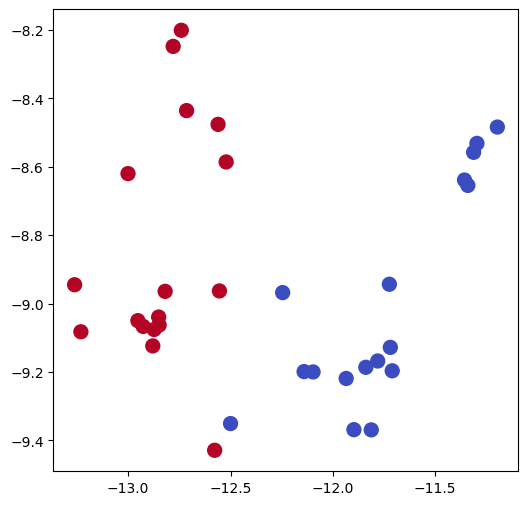

In [33]:
# Preprocess word vectors and label
nodes_wv = np.array([model.wv.get_vector(str(i)) for i in range(len(model.wv))])
labels = np.array(labels)

# Train TSNE
tsne = TSNE(n_components=2,
            learning_rate='auto',
            init='pca',
            random_state=0).fit_transform(nodes_wv)

# Plot TSNE
plt.figure(figsize=(6, 6))
plt.scatter(tsne[:, 0], tsne[:, 1], s=100, c=labels, cmap="coolwarm")
plt.show()

### Node classification task

DeepWalk provides an effective way to address node classification by learning low-dimensional vector representations of nodes that encode graph topology and node connectivity patterns.

The process involves:
1. **Embedding Generation**: Use DeepWalk to generate embeddings for each node by performing random walks and learning context-aware representations, similar to how Word2Vec processes sentences.
2. **Training a Classifier**: Use the node embeddings as input features for a machine learning classifier (e.g., logistic regression, SVM, or neural networks).
3. **Prediction**: Train the classifier on labeled nodes and predict the labels of unseen nodes.

This approach is scalable to large graphs and effective even with limited labeled data, as the embeddings capture both local and global graph structures. It is widely used in applications like social network analysis, citation networks, and biological networks to classify nodes based on their roles or attributes.

In [34]:
# Create masks to train and test the model
node_list = list(G_karate.nodes())
random.shuffle(node_list)

train_mask = node_list[:int(G_karate.order()*0.4)] # here we put 40% nodes in the training to have enough nodes for test the learnt model
test_mask = list(set(G_karate.nodes()) - set(train_mask))
print('Train mask:', train_mask)
print('Test mask:', test_mask)
# Train classifier
clf = RandomForestClassifier(random_state=0)
clf.fit(nodes_wv[train_mask], labels[train_mask])

# Evaluate accuracy
y_pred = clf.predict(nodes_wv[test_mask])
acc = accuracy_score(y_pred, labels[test_mask])
print(f'Accuracy = {acc*100:.2f}%')

Train mask: [18, 30, 21, 7, 4, 24, 28, 23, 9, 25, 33, 13, 5]
Test mask: [0, 1, 2, 3, 6, 8, 10, 11, 12, 14, 15, 16, 17, 19, 20, 22, 26, 27, 29, 31, 32]
Accuracy = 90.48%


In [35]:
# Create masks to train and test the model
train_mask = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]
test_mask = [0, 1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33]

# Train classifier
clf = RandomForestClassifier(random_state=0)
clf.fit(nodes_wv[train_mask], labels[train_mask])

# Evaluate accuracy
y_pred = clf.predict(nodes_wv[test_mask])
acc = accuracy_score(y_pred, labels[test_mask])
print(f'Accuracy = {acc*100:.2f}%')

Accuracy = 90.91%


## Improving Embeddings with Biased Random Walks in Node2Vec

![](slides/graph_ml_46.png)
![](slides/graph_ml_47.png)
![](slides/graph_ml_48.png)



**Node2Vec** enhances the process of learning graph embeddings by introducing **biased random walks**, enabling a flexible exploration of graph structures. Unlike traditional methods like **DeepWalk**, which uses uniform random walks, Node2Vec employs a parameterized framework to balance between **breadth-first search (BFS)** and **depth-first search (DFS)** traversal strategies. This adaptability allows Node2Vec to capture both local and global graph properties.

The key innovation lies in the design of the biased random walk:
1. **BFS-Like Behavior**: Encourages the exploration of nodes in the same neighborhood, capturing community or local clustering structures.
2. **DFS-Like Behavior**: Favors walking farther from the starting node, capturing roles and relationships across distant regions of the graph.

Two parameters, **return parameter (p)** and **in-out parameter (q)**, control this trade-off, enabling customized exploration suited to the task.

By leveraging biased random walks, Node2Vec produces embeddings that are more informative and adaptable to diverse graph tasks, such as classification, link prediction, and clustering, outperforming traditional uniform random-walk-based approaches.


In [37]:
def biased_random_walk(G, start, length, p, q):
    walk = [start]
    for i in range(length):
        current = walk[-1]
        previous = walk[-2] if len(walk) > 1 else None
        next = next_node(G, previous, current, p, q)
        walk.append(next)
    walk = [str(e) for e in walk]
    return walk

In [36]:
def next_node(G, previous, current, p, q):
    alphas = []

    # Get the neighboring nodes
    neighbors = list(G.neighbors(current))
    
    # Calculate the appropriate alpha value for each neighbor
    for neighbor in neighbors:
        # Distance = 0: probability to return to the previous node
        if neighbor == previous:
            alpha = 1/p
        # Distance = 1: probability of visiting a local node
        elif G.has_edge(neighbor, previous):
            alpha = 1
        # Distance = 2: probability to explore an unknown node
        else:
            alpha = 1/q
        alphas.append(alpha)

    # Normalize the alpha values to create transition probabilities
    probs = [alpha / sum(alphas) for alpha in alphas]
    
    # Randomly select the new node based on the transition probabilities
    next = int(np.random.choice(neighbors, size=1, p=probs)[0])
    return next

The function `next_node` calculates the next node in a **biased random walk** as part of the **Node2Vec** algorithm. The function uses parameters \( p \) and \( q \) to control the balance between **return probability**, **local exploration**, and **global exploration**, which are core aspects of Node2Vec's biased random walks.

- **Initialization**:
  - **`alphas`**: An empty list to store the unnormalized transition probabilities for each neighbor.
  - **`G.neighbors(current)`**: Retrieves the neighbors of the `current` node in the graph `G`.

---

```python
    # Calculate the appropriate alpha value for each neighbor
    for neighbor in neighbors:
        # Distance = 0: probability to return to the previous node
        if neighbor == previous:
            alpha = 1/p
        # Distance = 1: probability of visiting a local node
        elif G.has_edge(neighbor, previous):
            alpha = 1
        # Distance = 2: probability to explore an unknown node
        else:
            alpha = 1/q
        alphas.append(alpha)
```

- **Computing Transition Probabilities**:
  - For each neighboring node:
    - **Case 1: Distance = 0** (Return to the previous node):
      - If the neighbor is the `previous` node, the probability is scaled by \( 1/p \). A small \( p \) increases the likelihood of returning.
    - **Case 2: Distance = 1** (Visit a local neighbor):
      - If the neighbor is also connected to the `previous` node, it is considered a local neighbor, and the probability is set to 1.
    - **Case 3: Distance = 2** (Explore a distant node):
      - If the neighbor is not connected to the `previous` node, it is considered distant, and the probability is scaled by \( 1/q \). A small \( q \) increases the likelihood of exploring distant nodes.
  - Append the calculated alpha value to the `alphas` list.

---

```python
    # Normalize the alpha values to create transition probabilities
    probs = [alpha / sum(alphas) for alpha in alphas]
```

- **Normalization**:
  - The alpha values are normalized by dividing each by the total sum of `alphas` to create a valid probability distribution.
  - **`probs`**: Contains the transition probabilities for each neighbor.

---

```python
    # Randomly select the new node based on the transition probabilities
    next = np.random.choice(neighbors, size=1, p=probs)[0]
    return next
```

- **Node Selection**:
  - **`np.random.choice(neighbors, size=1, p=probs)`**: Selects a neighbor randomly based on the transition probabilities in `probs`.
  - **`[0]`**: Extracts the selected node from the returned array.
  - The function returns the selected `next` node.


**Control Parameters**:
   - **Return Parameter (\( p \))**:
     - Controls the likelihood of returning to the previous node.
     - Smaller \( p \): Higher return probability (local exploration).
     - Larger \( p \): Lower return probability.
   - **In-Out Parameter (\( q \))**:
     - Controls the likelihood of visiting distant nodes.
     - Smaller \( q \): Encourages global exploration (exploring nodes farther from the current node).
     - Larger \( q \): Favors local exploration (nodes close to the current node).

['0', '1', '9', '4', '7', '8', '7', '4', '6', '2', '1']


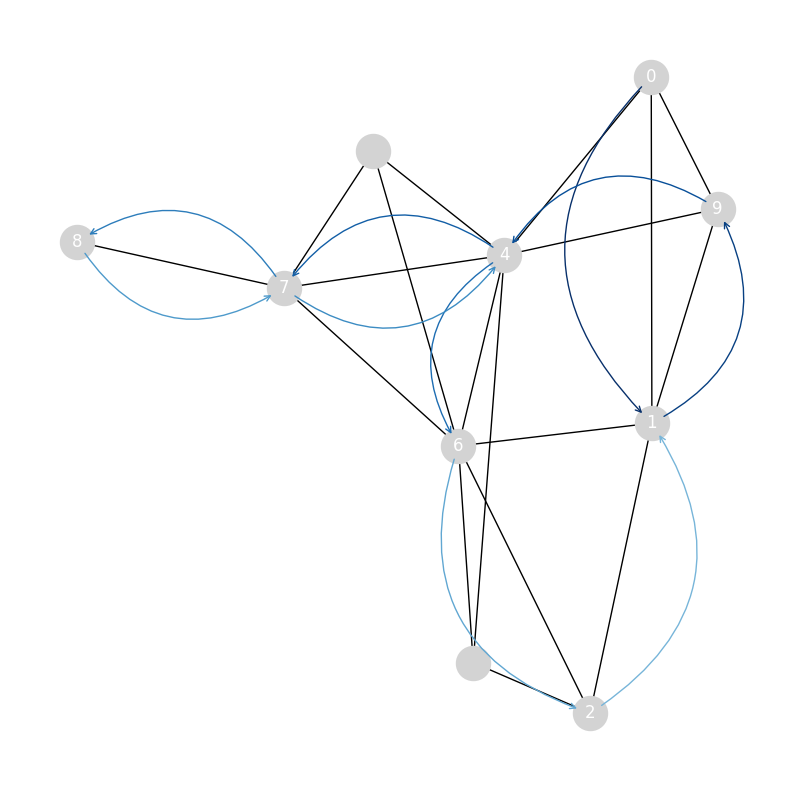

In [39]:
rw1 = biased_random_walk(G, 0, 10, p=1, q=1)
print(rw1)
Grw1 = draw_walk(G, rw1, pos, 'Blues_r')

['0', '9', '4', '9', '0', '4', '0', '4', '5', '6', '4']


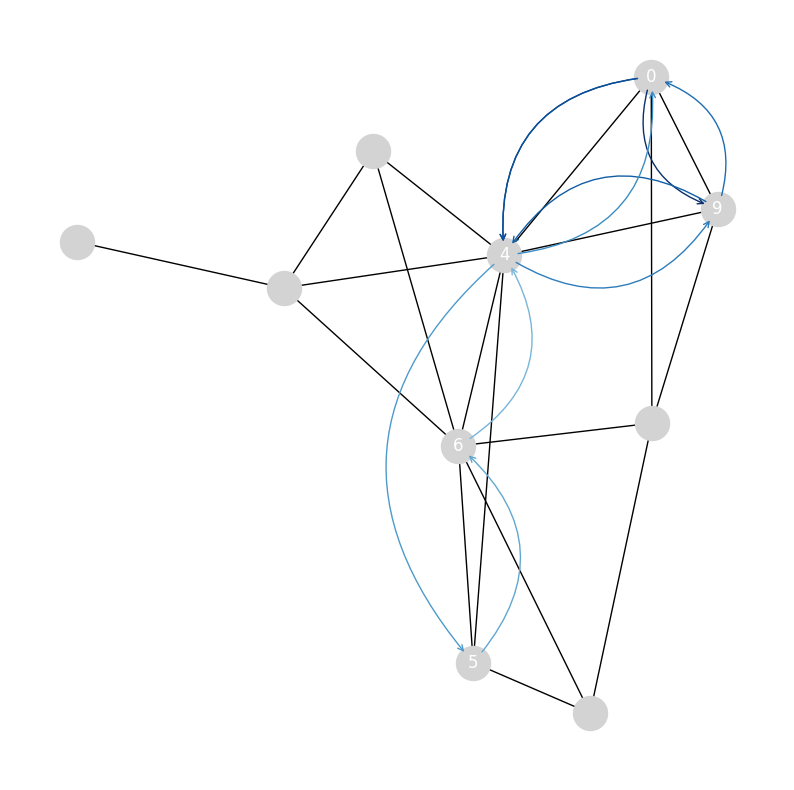

In [40]:
rw2 = biased_random_walk(G, 0, 10, p=1, q=10)
print(rw2)
Grw2 = draw_walk(G, rw2, pos,  'Blues_r')

['0', '9', '1', '2', '5', '2', '5', '4', '7', '3', '6']


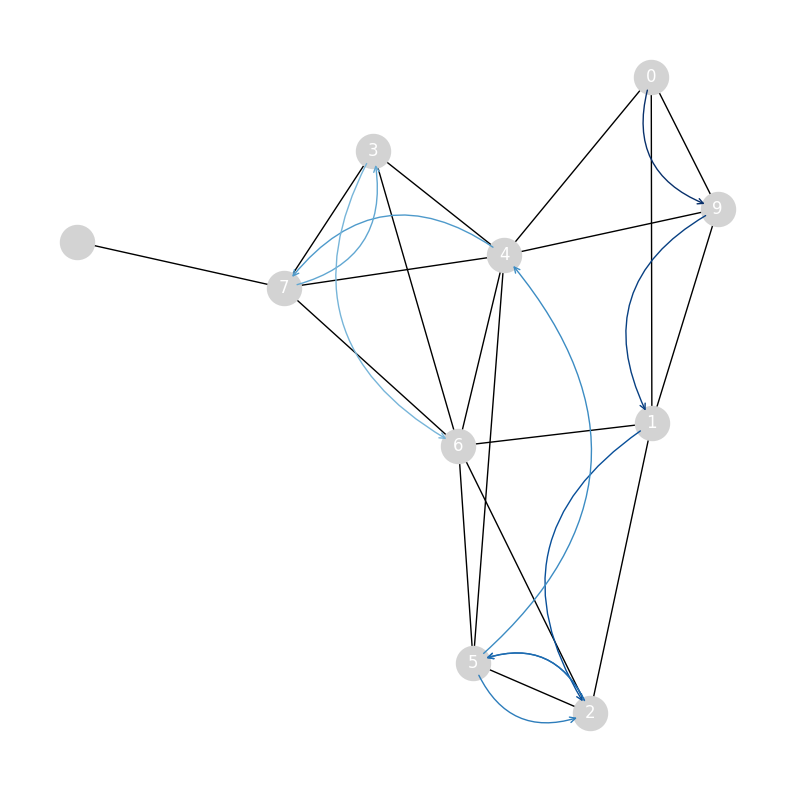

In [41]:
rw3 = biased_random_walk(G, 0, 10, p=10, q=1)
print(rw3)
Grw3 = draw_walk(G, rw3, pos, 'Blues_r')

### Example on Zachary's Karate club

In [43]:

# Process labels (Mr. Hi = 0, Officer = 1)
labels = []
for node in G_karate.nodes:
    label = G_karate.nodes[node]['club']
    labels.append(1 if label == 'Officer' else 0)
# Create a list of random walks
walks = []
for node in G_karate.nodes:
    for _ in range(80):
        walks.append(biased_random_walk(G_karate, node, 10, 7, 6))

# Create and train Word2Vec for DeepWalk
node2vec = Word2Vec(walks,
                hs=1,   # Hierarchical softmax
                sg=1,   # Skip-gram
                vector_size=100,
                window=5,
                workers=2,
                min_count=1,
                seed=0)
node2vec.train(walks, total_examples=node2vec.corpus_count, epochs=30, report_delay=1)

# Create masks to train and test the model
train_mask = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]
test_mask = [0, 1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33]
labels = np.array(labels)

# Train Node2Vec classifier
clf = RandomForestClassifier(random_state=0)
clf.fit(node2vec.wv[train_mask], labels[train_mask])

# Evaluate accuracy
y_pred = clf.predict(node2vec.wv[test_mask])
acc = accuracy_score(y_pred, labels[test_mask])
print(f'Node2Vec accuracy = {acc*100:.2f}%')

Node2Vec accuracy = 63.64%


__The Goal__: create a reccomendation system that suggest similar movies <br>
__The Dataset__: we use movielens dataset, that contains 100836 ratings made by 610 users for 9742 movies  <br>
__The Graph__: we want to create a graph where nodes are movies, and there is a link if they are similar--> users likes them both 

In [32]:
url = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
with urlopen(url) as zurl:
    with ZipFile(BytesIO(zurl.read())) as zfile:
        zfile.extractall('.')

In [33]:
ratings = pd.read_csv('ml-100k/u.data', sep='\t', names=['user_id', 'movie_id', 'rating', 'unix_timestamp'])
ratings

,user_id,movie_id,rating,unix_timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [35]:
movies = pd.read_csv('ml-100k/u.item', sep='|', usecols=range(2), names=['movie_id', 'title'], encoding='latin-1')
movies

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)
...,...,...
1677,1678,Mat' i syn (1997)
1678,1679,B. Monkey (1998)
1679,1680,Sliding Doors (1998)
1680,1681,You So Crazy (1994)


In [36]:
ratings = ratings[ratings.rating >= 4]
ratings

,user_id,movie_id,rating,unix_timestamp
5,298,474,4,884182806
7,253,465,5,891628467
11,286,1014,5,879781125
12,200,222,5,876042340
16,122,387,5,879270459
...,...,...,...,...
99988,421,498,4,892241344
99989,495,1091,4,888637503
99990,806,421,4,882388897
99991,676,538,4,892685437


In [37]:
from collections import defaultdict

pairs = defaultdict(int)

# Loop through the entire list of users
for group in ratings.groupby("user_id"):
    # List of IDs of movies rated by the current user
    user_movies = list(group[1]["movie_id"])

    # Count every time two movies are seen together
    for i in range(len(user_movies)):
        for j in range(i+1, len(user_movies)):
            pairs[(user_movies[i], user_movies[j])] += 1

In [38]:
# Create a networkx graph
G = nx.Graph()

# Try to create an edge between movies that are liked together
for pair in pairs:
    movie1, movie2 = pair
    score = pairs[pair]

    # The edge is only created when the score is high enough
    if score >= 20:
        G.add_edge(movie1, movie2, weight=score)

print("Total number of graph nodes:", G.number_of_nodes())
print("Total number of graph edges:", G.number_of_edges())

Total number of graph nodes: 410
Total number of graph edges: 14936


In [39]:
from node2vec import Node2Vec
node2vec = Node2Vec(G, dimensions=64, walk_length=20, num_walks=200, p=2, q=1, workers=1)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

/shared-libs/python3.9/py/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating walks (CPU: 1): 100%|██████████| 200/200 [00:34<00:00,  5.77it/s]


In [40]:
 def recommend(movie):
    movie_id = str(movies[movies.title == movie].movie_id.values[0])
    for id in model.wv.most_similar(movie_id)[:5]:
        title = movies[movies.movie_id == int(id[0])].title.values[0]
        print(f'{title}: {id[1]:.2f}')

recommend('Star Wars (1977)')

Return of the Jedi (1983): 0.64
Raiders of the Lost Ark (1981): 0.58
Toy Story (1995): 0.55
Silence of the Lambs, The (1991): 0.49
Monty Python and the Holy Grail (1974): 0.48


![](slides/graph_ml_49.png)
![](slides/graph_ml_50.png)
![](slides/graph_ml_51.png)
![](slides/graph_ml_52.png)
![](slides/graph_ml_53.png)
![](slides/graph_ml_54.png)

In [4]:
# Torch
import torch
torch.manual_seed(0)
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj

# PyGeometric
from torch_geometric.datasets import Planetoid, WikipediaNetwork
from torch_geometric.nn import GCNConv
import torch_geometric.transforms as T

Here we test the above methods on the **Cora citation network**, a classic benchmark in network science and graph machine learning. Each node represents a scientific article, edges encode citation links between articles, and every node is described by a high-dimensional vector of textual features extracted from the paper’s content. The task is a **multiclass node classification problem**: given the textual features (and, later, the network structure), we aim to predict the subject category of each paper. This setting is natural in many economic and health-related applications, where entities (firms, hospitals, patients, financial instruments) have both attributes and relations.

We will proceed in two steps, gradually increasing the role of the network:

* Fist, we treat Cora as a standard tabular dataset and train a **Multilayer Perceptron (MLP)** that uses only the node features, completely ignoring citation links.
* Next, we explicitly introduce the **adjacency matrix** of the citation graph and design a simple, ad-hoc **vanilla graph layer** that aggregates information from neighbors.
* Finally, we compare the two approaches to highlight how exploiting the network structure can improve classification performance and provide more realistic models of interconnected economic and health systems.


In [7]:
# Import dataset from PyTorch Geometric
dataset = Planetoid(root=".", name="Cora")
data = dataset[0]

# Print information about the dataset
print(f'Dataset: {dataset}')
print('---------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print information about the graph
print(f'\nGraph:')
print('------')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

Processing...
Done!
Dataset: Cora()
---------------
Number of graphs: 1
Number of nodes: 2708
Number of features: 1433
Number of classes: 7

Graph:
------
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: False


If we use a standard MLP approach, we have to build a tabular representation of the nodes in the Cora graph.

In [6]:
df_x = pd.DataFrame(data.x.numpy()) # data.x contains the feature vectors
df_x['label'] = pd.DataFrame(data.y) #data.y contains the labels for each node
df_x

,0,1,2,3,4,5,6,7,8,9,...,1424,1425,1426,1427,1428,1429,1430,1431,1432,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2703,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2704,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2705,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2706,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


#### MLP
We define a simple MLP with a single hidden layer with `dim_h` hidden units. As activation funciont we use the ReLU function and a `softmax` layer in the output since we are dealing with a multiclass classification task.

In [19]:
def accuracy(y_pred, y_true):
    """Calculate accuracy."""
    return torch.sum(y_pred == y_true) / len(y_true)


class MLP(torch.nn.Module):
    """Multilayer Perceptron"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.linear1 = Linear(dim_in, dim_h) # W_0 from input to hideen layer
        self.linear2 = Linear(dim_h, dim_out) # W_1 from hidden layer to output layer

    def forward(self, x):
        x = self.linear1(x)
        x = torch.relu(x) # ReLU activation function
        x = self.linear2(x)
        return F.log_softmax(x, dim=1)

    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss() # loss function suitable for multiclass classification
        optimizer = torch.optim.Adam(self.parameters(),
                                          lr=0.01,
                                          weight_decay=5e-4) # algorithm for weight updates based on gradient

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad() 
            out = self(data.x)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1),
                          data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1),
                                  data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()      
    def test(self, data):
        self.eval()
        out = self(data.x)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

# Create MLP model
mlp = MLP(dataset.num_features, 16, dataset.num_classes)
print(mlp)

# Train
mlp.fit(data, epochs=100)

# Test
acc = mlp.test(data)
print(f'\nMLP test accuracy: {acc*100:.2f}%')

MLP(
  (linear1): Linear(in_features=1433, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=7, bias=True)
)
Epoch   0 | Train Loss: 1.952 | Train Acc: 14.29% | Val Loss: 1.97 | Val Acc: 5.80%
Epoch  20 | Train Loss: 0.111 | Train Acc: 100.00% | Val Loss: 1.43 | Val Acc: 53.80%
Epoch  40 | Train Loss: 0.014 | Train Acc: 100.00% | Val Loss: 1.48 | Val Acc: 51.80%
Epoch  60 | Train Loss: 0.008 | Train Acc: 100.00% | Val Loss: 1.44 | Val Acc: 52.40%
Epoch  80 | Train Loss: 0.009 | Train Acc: 100.00% | Val Loss: 1.38 | Val Acc: 53.00%
Epoch 100 | Train Loss: 0.009 | Train Acc: 100.00% | Val Loss: 1.36 | Val Acc: 53.40%

MLP test accuracy: 54.40%


#### Vanilla GNN

In [10]:
class VanillaGNNLayer(torch.nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.linear = Linear(dim_in, dim_out, bias=False)

    def forward(self, x, adjacency):
        x = self.linear(x) # X * W
        x = torch.sparse.mm(adjacency, x) # here's the trick: multiply the adj matrix with the feature vector!  => A * X * W
        return x

The adjacency matrix itself it's not enought, we need to add also self loops (sum with identitiy matrix) so that we consider also the node itself and no just its neighbors

In [22]:
adjacency = to_dense_adj(data.edge_index)[0] # torch requires the matrix to be dense (instead of sparse)!
adjacency += torch.eye(len(adjacency)) 
adjacency

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 1.],
        [0., 0., 0.,  ..., 0., 1., 1.]])

In [25]:
class VanillaGNN(torch.nn.Module):
    """Vanilla Graph Neural Network"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gnn1 = VanillaGNNLayer(dim_in, dim_h)
        self.gnn2 = VanillaGNNLayer(dim_h, dim_out)

    def forward(self, x, adjacency):
        h = self.gnn1(x, adjacency) # the adjacency matrix is fixed in all the layers
        h = torch.relu(h)
        h = self.gnn2(h, adjacency)
        return F.log_softmax(h, dim=1)

    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(),
                                      lr=0.01,
                                      weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, adjacency)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1),
                          data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1),
                                  data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, adjacency)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

# Create the Vanilla GNN model
gnn = VanillaGNN(dataset.num_features, 16, dataset.num_classes)
print(gnn)

# Train
gnn.fit(data, epochs=100)

# Test
acc = gnn.test(data)
print(f'\nGNN test accuracy: {acc*100:.2f}%')

VanillaGNN(
  (gnn1): VanillaGNNLayer(
    (linear): Linear(in_features=1433, out_features=16, bias=False)
  )
  (gnn2): VanillaGNNLayer(
    (linear): Linear(in_features=16, out_features=7, bias=False)
  )
)
Epoch   0 | Train Loss: 2.381 | Train Acc:  7.86% | Val Loss: 2.16 | Val Acc: 18.80%
Epoch  20 | Train Loss: 0.100 | Train Acc: 99.29% | Val Loss: 1.52 | Val Acc: 74.80%
Epoch  40 | Train Loss: 0.007 | Train Acc: 100.00% | Val Loss: 2.29 | Val Acc: 74.00%
Epoch  60 | Train Loss: 0.002 | Train Acc: 100.00% | Val Loss: 2.50 | Val Acc: 74.20%
Epoch  80 | Train Loss: 0.002 | Train Acc: 100.00% | Val Loss: 2.50 | Val Acc: 74.00%
Epoch 100 | Train Loss: 0.002 | Train Acc: 100.00% | Val Loss: 2.46 | Val Acc: 74.20%

GNN test accuracy: 75.10%


#### Graph Convolutional Layer - GCN

In [28]:
class GCN(torch.nn.Module):
    """Graph Convolutional Network"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gcn1 = GCNConv(dim_in, dim_h)
        self.gcn2 = GCNConv(dim_h, dim_out)

    def forward(self, x, edge_index):
        h = self.gcn1(x, edge_index)
        h = torch.relu(h)
        h = self.gcn2(h, edge_index)
        return F.log_softmax(h, dim=1)

    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(),
                                      lr=0.01,
                                      weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1),
                          data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1),
                                  data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

# Create the Vanilla GNN model
gcn = GCN(dataset.num_features, 16, dataset.num_classes)
print(gcn)

# Train
gcn.fit(data, epochs=100)

# Test
acc = gcn.test(data)
print(f'\nGCN test accuracy: {acc*100:.2f}%\n')

GCN(
  (gcn1): GCNConv(1433, 16)
  (gcn2): GCNConv(16, 7)
)
Epoch   0 | Train Loss: 1.946 | Train Acc: 18.57% | Val Loss: 1.95 | Val Acc: 16.40%
Epoch  20 | Train Loss: 0.123 | Train Acc: 100.00% | Val Loss: 0.78 | Val Acc: 77.60%
Epoch  40 | Train Loss: 0.016 | Train Acc: 100.00% | Val Loss: 0.77 | Val Acc: 75.80%
Epoch  60 | Train Loss: 0.015 | Train Acc: 100.00% | Val Loss: 0.74 | Val Acc: 77.40%
Epoch  80 | Train Loss: 0.018 | Train Acc: 100.00% | Val Loss: 0.73 | Val Acc: 77.60%
Epoch 100 | Train Loss: 0.016 | Train Acc: 100.00% | Val Loss: 0.73 | Val Acc: 77.80%

GCN test accuracy: 79.90%



**Node regression: predicting traffic on web pages**